# Исследование гендерного разрыва в заработных платах

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import pyreadstat
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from scipy import stats
from statsmodels.stats.diagnostic import het_breuschpagan, het_white, linear_reset
from statsmodels.stats.outliers_influence import variance_inflation_factor


In [2]:
DATA_PATH = "метрика бд.sav"
YEAR_KEEP = [2019, 2024]
REGION_CODES = [45, 141]
SPB_CODE = 141
CPI = {2019: 100.0, 2024: 149.75}
HOURS_COL = "hours of work per week"


In [3]:
def load_data(path: str) -> pd.DataFrame:
    needed_cols = [
        "year",
        "region",
        "popul",
        "h5",
        "age",
        "diplom",
        "j260",
        "educ",
        "marst",
        "j72.173",
        "occup08",
        "j4.1",
        "j6.2",
        "j26",
        "j21.3",
        "j13.2",
    ]

    df, meta = pyreadstat.read_sav(path, usecols=needed_cols)

    # стандартные коды пропусков RLMS / SPSS-подобные
    missing_codes = [99999996, 99999997, 99999998, 99999999]
    df = df.replace(missing_codes, np.nan)

    # оставляем только нужные годы и регионы
    df = df[df["year"].isin(YEAR_KEEP)].copy()
    df = df[df["region"].isin(REGION_CODES)].copy()

    # убираем пропуски и нули по зарплате
    df = df.dropna(subset=["j13.2"]).copy()
    df = df[df["j13.2"] > 0].copy()

    # дефляция зарплаты к ценам 2019 года
    df["cpi"] = df["year"].map(CPI)
    df["wage"] = df["j13.2"] / (df["cpi"] / 100.0)

    # rename для удобства
    df = df.rename(columns={
        "j4.1": "industry",
        "j6.2": HOURS_COL,
        "j21.3": "work_danger",
        "h5": "sex",
        "j26": "ownering",
        "j260": "language",
        "j72.173": "children",
    })

    return df.reset_index(drop=True)

In [10]:
def add_binary_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    out["female"] = (out["sex"] == 2).astype(int)
    out["danger"] = (out["work_danger"] == 1).astype(int)
    out["lang"] = (out["language"] == 1).astype(int)
    out["spb"] = (out["region"] == SPB_CODE).astype(int)
    out["owner"] = (out["ownering"] == 1).astype(int)
    out["year_2024"] = (out["year"] == 2024).astype(int)

    return out


def add_grouped_categories(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    # education groups
    out["edu_group"] = np.select(
        [
            out["diplom"].isin([1, 2, 3]),
            out["diplom"] == 4,
            out["diplom"] == 5,
            out["diplom"] == 6,
        ],
        [
            "below_secondary",
            "secondary",
            "vocational",
            "higher",
        ],
        default=None,
    )

    # marital status groups
    out["marst_group"] = np.select(
        [
            out["marst"].eq(1),
            out["marst"].isin([2, 3, 7]),
            out["marst"].eq(6),
            out["marst"].isin([4, 5]),
        ],
        [
            "single_never",
            "married_or_partnered",
            "separated",
            "previously_married",
        ],
        default=None,
    )

    # occupation groups
    out["occup_group"] = np.select(
        [
            out["occup08"].isin([0, 1, 2]),
            out["occup08"].isin([3, 4]),
            out["occup08"].isin([5, 6, 7, 8]),
            out["occup08"] == 9,
        ],
        [
            "high_skill",
            "mid_skill_white",
            "skilled_blue",
            "low_skill",
        ],
        default=None,
    )

    # industry groups
    out["industry_group"] = np.select(
        [
            out["industry"].isin([1, 2, 3, 4, 5, 16, 23, 24]),
            out["industry"].isin([6, 7, 17]),
            out["industry"].isin([9, 10, 11, 12, 13, 20, 21]),
            out["industry"].isin([14, 25, 26, 29]),
            out["industry"].isin([15, 18, 27, 30, 31]),
            out["industry"].isin([8, 22, 28, 32]),
        ],
        [
            "manufacturing",
            "construction_transport",
            "public_sector",
            "trade_services",
            "finance_it_media",
            "other",
        ],
        default=None,
    )

    # dummies
    out = pd.get_dummies(out, columns=["edu_group"], prefix="edu", drop_first=False)
    out = pd.get_dummies(out, columns=["marst_group"], prefix="marst", drop_first=False)
    out = pd.get_dummies(out, columns=["occup_group"], prefix="occup", drop_first=False)
    out = pd.get_dummies(out, columns=["industry_group"], prefix="ind", drop_first=False)

    bool_cols = out.select_dtypes(include="bool").columns
    out[bool_cols] = out[bool_cols].astype(int)

    return out


def build_model_frame(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    # лог зависимой
    out = out[out["wage"].notna() & (out["wage"] > 0)].copy()
    out["ln_wage"] = np.log(out["wage"])

    # центрированный возраст + квадрат
    out["age_c"] = out["age"] - out["age"].mean()
    out["age_c2"] = out["age_c"] ** 2

    # interactions
    out["female_x_year_2024"] = out["female"] * out["year_2024"]
    out["eduH_x_finIT"] = out["edu_higher"] * out["ind_finance_it_media"]

    return out

In [5]:
def plot_basic_eda(df: pd.DataFrame) -> None:
    corr_candidates = [
        "wage", "year_2024", "female", "age", "spb", HOURS_COL,
        "children", "owner", "danger", "lang", "popul"
    ]
    corr_candidates = [c for c in corr_candidates if c in df.columns]
    corr = df[corr_candidates].corr(numeric_only=True)

    mask = np.triu(np.ones_like(corr, dtype=bool))
    np.fill_diagonal(mask, True)

    plt.figure(figsize=(9, 7))
    sns.heatmap(
        corr, mask=mask, annot=True, fmt=".2f",
        cmap="coolwarm", center=0, vmin=-1, vmax=1,
        square=True, linewidths=0.5
    )
    plt.title("Корреляционная матрица (нижний треугольник)")
    plt.tight_layout()
    plt.show()

    # wage and ln(wage)
    plt.figure(figsize=(8, 4))
    plt.hist(df["wage"], bins=50)
    plt.title("Распределение wage (реальная зарплата, цены 2019)")
    plt.xlabel("wage")
    plt.ylabel("Частота")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.hist(df["ln_wage"], bins=50)
    plt.title("Распределение ln(wage)")
    plt.xlabel("ln(wage)")
    plt.ylabel("Частота")
    plt.tight_layout()
    plt.show()

    # scatter plots
    for var in ["age", HOURS_COL, "children"]:
        if var in df.columns:
            plt.figure(figsize=(6, 4))
            sns.regplot(
                data=df, x=var, y="wage",
                scatter_kws={"alpha": 0.35}, ci=None
            )
            plt.title(f"{var} и wage")
            plt.tight_layout()
            plt.show()

In [6]:
def fit_ols(data: pd.DataFrame, y: str, x_cols: list[str]):
    d = data[[y] + x_cols].dropna().copy()
    X = sm.add_constant(d[x_cols], has_constant="add")
    yv = d[y]
    model = sm.OLS(yv, X).fit()
    model_rob = model.get_robustcov_results(cov_type="HC1")
    return model, model_rob


def run_functional_form_check(df: pd.DataFrame) -> pd.DataFrame:
    x_cols = ["female", "age", "edu_secondary", "edu_vocational", "edu_higher", HOURS_COL]
    d = df[["wage", "ln_wage"] + x_cols].dropna().copy()

    X = sm.add_constant(d[x_cols], has_constant="add")
    m_level = sm.OLS(d["wage"], X).fit()
    m_log = sm.OLS(d["ln_wage"], X).fit()

    rows = []
    for name, model in [("wage", m_level), ("ln(wage)", m_log)]:
        bp = het_breuschpagan(model.resid, model.model.exog)
        w = het_white(model.resid, model.model.exog)
        rst = linear_reset(model, power=2, use_f=True)
        rows.append({
            "dependent_variable": name,
            "Breusch_Pagan_pvalue": float(bp[1]),
            "White_pvalue": float(w[1]),
            "RESET_pvalue": float(rst.pvalue),
        })

    return pd.DataFrame(rows)


def chow_test(df: pd.DataFrame, y: str, x_cols: list[str], split_col: str = "year_2024") -> dict:
    d = df[[y, split_col] + x_cols].dropna().copy()

    d0 = d[d[split_col] == 0].copy()
    d1 = d[d[split_col] == 1].copy()

    X_pool = sm.add_constant(d[x_cols], has_constant="add")
    X0 = sm.add_constant(d0[x_cols], has_constant="add")
    X1 = sm.add_constant(d1[x_cols], has_constant="add")

    m_pool = sm.OLS(d[y], X_pool).fit()
    m0 = sm.OLS(d0[y], X0).fit()
    m1 = sm.OLS(d1[y], X1).fit()

    sse_pool = float(np.sum(m_pool.resid ** 2))
    sse_sep = float(np.sum(m0.resid ** 2) + np.sum(m1.resid ** 2))

    k = X_pool.shape[1]
    n0 = X0.shape[0]
    n1 = X1.shape[0]

    F = ((sse_pool - sse_sep) / k) / (sse_sep / (n0 + n1 - 2 * k))
    pvalue = 1 - stats.f.cdf(F, k, n0 + n1 - 2 * k)

    return {
        "F_stat": F,
        "pvalue": pvalue,
        "n_pool": X_pool.shape[0],
        "k": k,
    }


def calc_vif(X: pd.DataFrame) -> float:
    cols = [c for c in X.columns if c != "const"]
    if len(cols) == 0:
        return np.nan

    Xv = X[cols].astype(float)
    vifs = [variance_inflation_factor(Xv.values, i) for i in range(Xv.shape[1])]
    return float(np.nanmax(vifs))


def diagnostics_table(models_raw: dict) -> pd.DataFrame:
    rows = []

    for name, m in models_raw.items():
        X = pd.DataFrame(m.model.exog, columns=m.model.exog_names)
        resid = m.resid

        bp = het_breuschpagan(resid, m.model.exog)
        try:
            w = het_white(resid, m.model.exog)
            white_p = float(w[1])
        except Exception:
            white_p = np.nan

        try:
            rst = linear_reset(m, power=2, use_f=True)
            reset_p = float(rst.pvalue)
        except Exception:
            reset_p = np.nan

        rank_ok = (np.linalg.matrix_rank(m.model.exog) == m.model.exog.shape[1])

        rows.append({
            "model": name,
            "N": int(m.nobs),
            "R2": float(m.rsquared),
            "Adj_R2": float(m.rsquared_adj),
            "Rank_full": rank_ok,
            "BP_pvalue": float(bp[1]),
            "White_pvalue": white_p,
            "RESET_pvalue": reset_p,
            "Max_VIF": calc_vif(X),
        })

    return pd.DataFrame(rows).set_index("model").sort_index()

In [7]:
def get_model_specs() -> dict:
    return {
        # M1: базовая модель
        "M1": [
            "female", "year_2024", "age_c",
            "edu_secondary", "edu_vocational", "edu_higher",
            HOURS_COL
        ],

        # M2: + нелинейность возраста + female×year + finance/IT/media
        "M2": [
            "female", "year_2024", "female_x_year_2024", "age_c", "age_c2",
            "edu_secondary", "edu_vocational", "edu_higher",
            HOURS_COL, "ind_finance_it_media"
        ],

        # M3: + interaction + risk + region
        "M3": [
            "female", "year_2024", "female_x_year_2024", "age_c", "age_c2",
            "edu_secondary", "edu_vocational", "edu_higher",
            HOURS_COL, "danger", "spb",
            "ind_finance_it_media", "eduH_x_finIT"
        ],

        # M4: расширенная спецификация
        "M4": [
            "female", "year_2024", "female_x_year_2024", "age_c", "age_c2",
            "edu_secondary", "edu_vocational", "edu_higher",
            HOURS_COL, "danger", "spb", "owner",
            "ind_finance_it_media", "ind_public_sector", "ind_trade_services",
            "marst_married_or_partnered", "marst_previously_married",
            "occup_mid_skill_white", "occup_skilled_blue"
        ],
    }


def fit_all_models(df: pd.DataFrame):
    specs = get_model_specs()

    models_raw = {}
    models_rob = {}

    for name, x_cols in specs.items():
        m_raw, m_rob = fit_ols(df, "ln_wage", x_cols)
        models_raw[name] = m_raw
        models_rob[name] = m_rob

    return specs, models_raw, models_rob

In [8]:
def stars(p):
    if p < 0.01:
        return "***"
    if p < 0.05:
        return "**"
    if p < 0.10:
        return "*"
    return ""

def regression_table(models_raw: dict, models_rob: dict) -> pd.DataFrame:
    vars_order = [
        "female",
        "year_2024",
        "female_x_year_2024",
        "age_c",
        "age_c2",
        "edu_secondary",
        "edu_vocational",
        "edu_higher",
        HOURS_COL,
        "danger",
        "spb",
        "owner",
        "eduH_x_finIT",
        "ind_finance_it_media",
        "ind_public_sector",
        "ind_trade_services",
        "marst_married_or_partnered",
        "marst_previously_married",
        "occup_mid_skill_white",
        "occup_skilled_blue",
        "const",
    ]

    table = pd.DataFrame(index=vars_order)

    for name in models_raw.keys():
        raw = models_raw[name]
        rob = models_rob[name]

        exog_names = list(raw.model.exog_names)
        params = pd.Series(np.asarray(rob.params), index=exog_names)
        bse = pd.Series(np.asarray(rob.bse), index=exog_names)
        pvals = pd.Series(np.asarray(rob.pvalues), index=exog_names)

        col = []
        for var in vars_order:
            if var in params.index:
                col.append(f"{params[var]:.4f}{stars(pvals[var])}\n({bse[var]:.4f})")
            else:
                col.append("")
        table[name] = col

    return table


def female_effects_table(models_raw: dict, models_rob: dict) -> pd.DataFrame:
    rows = []

    for name in models_raw.keys():
        raw = models_raw[name]
        rob = models_rob[name]
        exog_names = list(raw.model.exog_names)
        params = pd.Series(np.asarray(rob.params), index=exog_names)

        beta = float(params["female"])
        pct = 100 * (np.exp(beta) - 1)

        rows.append({
            "model": name,
            "female_beta": beta,
            "female_effect_percent": pct,
        })

    return pd.DataFrame(rows).set_index("model")

In [11]:
# Подготовка данных
df = load_data(DATA_PATH)
df = add_binary_features(df)
df = add_grouped_categories(df)
df = build_model_frame(df)

print("Shape after cleaning:", df.shape)
print("Years:", df["year"].value_counts(dropna=False).to_dict())
print("Regions:", df["region"].value_counts(dropna=False).to_dict())
df.head()


Shape after cleaning: (890, 47)
Years: {2019.0: 462, 2024.0: 428}
Regions: {141.0: 481, 45.0: 409}


,year,region,popul,marst,occup08,educ,diplom,sex,age,industry,...,ind_finance_it_media,ind_manufacturing,ind_other,ind_public_sector,ind_trade_services,ln_wage,age_c,age_c2,female_x_year_2024,eduH_x_finIT
0,2019.0,45.0,1257400.0,2.0,7.0,16.0,4.0,2.0,52.5,3.0,...,0,1,0,0,0,9.740969,9.780899,95.665983,0,0
1,2019.0,45.0,1257400.0,2.0,8.0,16.0,4.0,1.0,55.0,9.0,...,0,0,0,1,0,10.463103,12.280899,150.820477,0,0
2,2019.0,45.0,1257400.0,1.0,8.0,19.0,5.0,1.0,32.0,9.0,...,0,0,0,1,0,10.463103,-10.719101,114.899129,0,0
3,2019.0,45.0,1257400.0,5.0,5.0,18.0,5.0,2.0,55.0,7.0,...,0,0,0,0,0,9.615805,12.280899,150.820477,0,0
4,2019.0,45.0,1257400.0,1.0,5.0,14.0,4.0,1.0,23.0,13.0,...,0,0,0,1,0,10.308953,-19.719101,388.842949,0,0


## Сравнение спецификации в уровнях и логарифмах

In [12]:
functional_form_table = run_functional_form_check(df)
functional_form_table.round(4)

,dependent_variable,Breusch_Pagan_pvalue,White_pvalue,RESET_pvalue
0,wage,0.0005,0.0128,0.1317
1,ln(wage),0.0105,0.0043,0.0010


## Тест Чоу

In [13]:
chow_x = [
    "female", "age_c", "age_c2",
    "edu_secondary", "edu_vocational", "edu_higher",
    HOURS_COL, "danger", "spb"
]
chow_res = chow_test(df, "ln_wage", chow_x, split_col="year_2024")
pd.DataFrame([chow_res]).round(4)


,F_stat,pvalue,n_pool,k
0,3.5677,0.0001,851,10


## Оценка моделей M1–M4

In [14]:
specs, models_raw, models_rob = fit_all_models(df)
print(specs)

{'M1': ['female', 'year_2024', 'age_c', 'edu_secondary', 'edu_vocational', 'edu_higher', 'hours of work per week'], 'M2': ['female', 'year_2024', 'female_x_year_2024', 'age_c', 'age_c2', 'edu_secondary', 'edu_vocational', 'edu_higher', 'hours of work per week', 'ind_finance_it_media'], 'M3': ['female', 'year_2024', 'female_x_year_2024', 'age_c', 'age_c2', 'edu_secondary', 'edu_vocational', 'edu_higher', 'hours of work per week', 'danger', 'spb', 'ind_finance_it_media', 'eduH_x_finIT'], 'M4': ['female', 'year_2024', 'female_x_year_2024', 'age_c', 'age_c2', 'edu_secondary', 'edu_vocational', 'edu_higher', 'hours of work per week', 'danger', 'spb', 'owner', 'ind_finance_it_media', 'ind_public_sector', 'ind_trade_services', 'marst_married_or_partnered', 'marst_previously_married', 'occup_mid_skill_white', 'occup_skilled_blue']}


In [15]:
reg_table = regression_table(models_raw, models_rob)
reg_table

,M1,M2,M3,M4
female,-0.2731***\n(0.0318),-0.2733***\n(0.0436),-0.2682***\n(0.0419),-0.2234***\n(0.0421)
year_2024,0.1583***\n(0.0311),0.1442***\n(0.0451),0.1258***\n(0.0446),0.1326***\n(0.0427)
female_x_year_2024,,-0.0020\n(0.0598),0.0043\n(0.0579),0.0208\n(0.0562)
age_c,-0.0047***\n(0.0013),-0.0020\n(0.0013),-0.0025**\n(0.0012),-0.0041***\n(0.0014)
age_c2,,-0.0005***\n(0.0001),-0.0005***\n(0.0001),-0.0004***\n(0.0001)
edu_secondary,0.2257***\n(0.0698),0.1941***\n(0.0677),0.1796***\n(0.0690),0.1840**\n(0.0721)
edu_vocational,0.2731***\n(0.0704),0.2531***\n(0.0678),0.2508***\n(0.0691),0.2445***\n(0.0731)
edu_higher,0.4708***\n(0.0697),0.4269***\n(0.0677),0.4379***\n(0.0700),0.4267***\n(0.0743)
hours of work per week,0.0079***\n(0.0018),0.0068***\n(0.0018),0.0080***\n(0.0019),0.0081***\n(0.0021)
danger,,,0.1393***\n(0.0467),0.1736***\n(0.0463)


In [16]:
gm_table = diagnostics_table(models_raw)
gm_table.round(4)

,N,R2,Adj_R2,Rank_full,BP_pvalue,White_pvalue,RESET_pvalue,Max_VIF
model,,,,,,,,
M1,851,0.2018,0.1951,True,0.0078,0.0053,0.0490,9.6776
M2,851,0.2378,0.2287,True,0.0065,0.0093,0.5297,10.0186
M3,851,0.2935,0.2825,True,0.0229,0.0018,0.0036,10.0943
M4,851,0.3375,0.3223,True,0.0858,0.0002,0.0518,13.7374


In [17]:
female_table = female_effects_table(models_raw, models_rob)
female_table.round(4)

,female_beta,female_effect_percent
model,,
M1,-0.2731,-23.8976
M2,-0.2733,-23.9105
M3,-0.2682,-23.5253
M4,-0.2234,-20.0203


## Графики

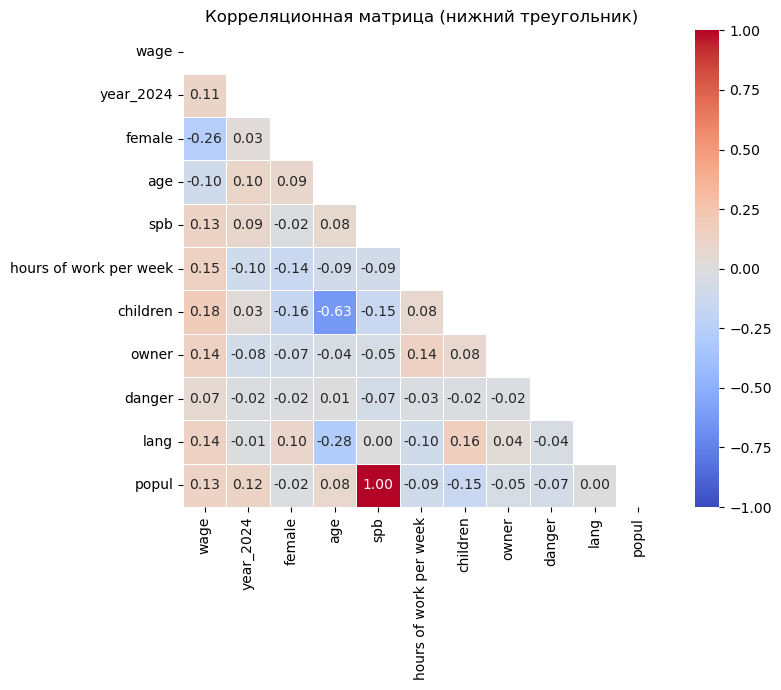

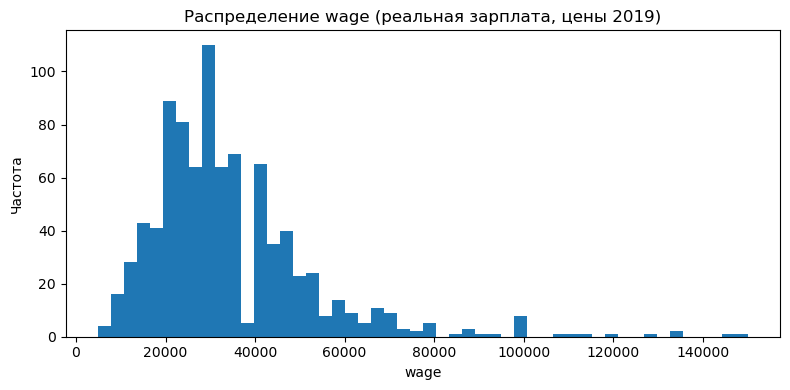

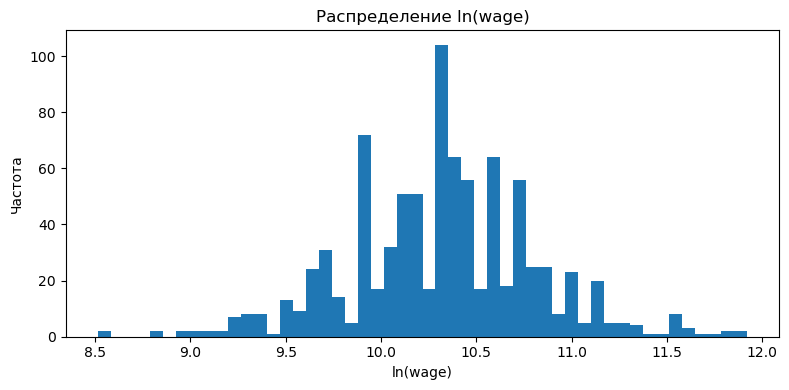

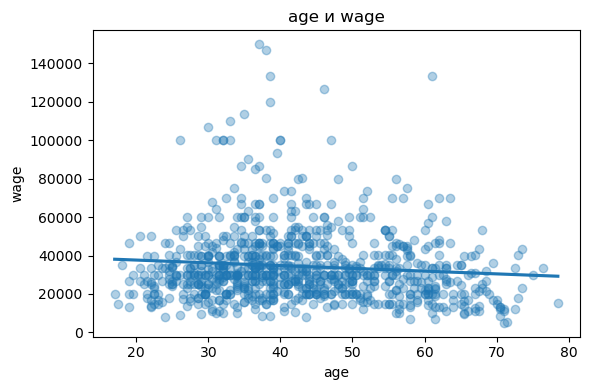

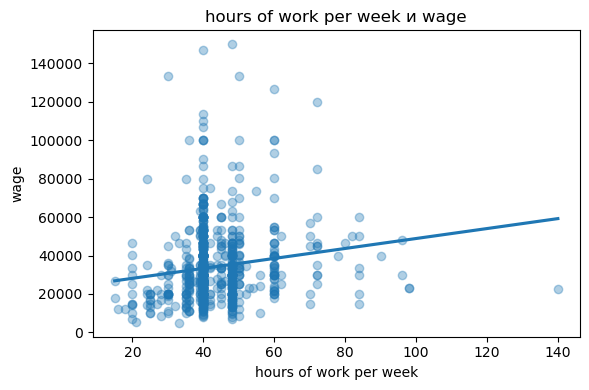

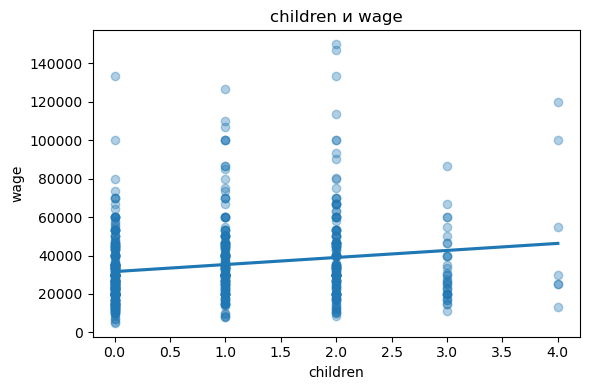

In [18]:
plot_basic_eda(df)